# Host PD Saturation (Fig. 3C-style)

This notebook reproduces a **Fig. 3C-style cumulative phylogenetic diversity (PD) saturation analysis** for host-virus associations, aligned to the logic in `/Users/ricardorivero/Downloads/fig-3-saturation.ipynb`.

Core idea (**Dudas Fig 3C concept**): for each virus, hosts are added by **first report year** (ties added as a batch), and we track:
- cumulative Faith's PD, `PD(S_i)`
- marginal gains, `ΔPD_i = PD(S_i) - PD(S_{i-1})`

Outputs include per-virus curves, exemplar viruses, permutation envelopes, and Arena-vs-Hanta group summaries.


In [16]:
# Environment, imports, reproducibility
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dendropy

GLOBAL_SEED = 1
rng = np.random.default_rng(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10


In [17]:
# Parameters (edit here)
CSV_PATH = Path('/Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/pathogen_taxonomy_pcr.csv')
HOST_TREE_PATH = Path('/Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/cophylogeny/arha_upham_hosts_hanta_arena_linked.nwk')
OUTPUT_DIR = Path('/Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/cophylogeny/pd_saturation_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional explicit column overrides (harmonized taxonomy is assigned_name)
COL_VIRUS = 'assigned_name'
COL_HOST = None
COL_YEAR = None
COL_GROUP = None

# Optional host label mapping file (2 cols: raw_label, tree_label)
HOST_LABEL_MAP_PATH = None

# Optional virus->group mapping file (2 cols: virus_id, group)
VIRUS_GROUP_MAP_PATH = None

# Drop these harmonized taxa from analysis (exact match on assigned_name)
DROP_VIRUS_NAMES = [
    'unclassified Orthohantavirus',
    'unclassified Mammarenavirus',
    'Hantaviridae',
    'Arenaviridae',
    'Unclassified Arenaviridae',
]

# Late-phase cutoff years (None => auto-set to full dataset span after cleaning)
Y0 = None
Y0_ALT = None

# Permutations for random-order envelopes
R_PERM = 10000

# Exemplar count
N_EXEMPLARS = 6

# Figure export formats
SAVE_FORMATS = ['png', 'pdf']

print('CSV_PATH:', CSV_PATH)
print('HOST_TREE_PATH:', HOST_TREE_PATH)
print('OUTPUT_DIR:', OUTPUT_DIR)


CSV_PATH: /Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/pathogen_taxonomy_pcr.csv
HOST_TREE_PATH: /Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/cophylogeny/arha_upham_hosts_hanta_arena_linked.nwk
OUTPUT_DIR: /Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/cophylogeny/pd_saturation_outputs


In [18]:
# Load required CSV and inspect columns
if not CSV_PATH.exists():
    raise FileNotFoundError(f'Required input file not found: {CSV_PATH}')

raw = pd.read_csv(CSV_PATH, low_memory=False)
print('Shape:', raw.shape)
print('Columns:')
for c in raw.columns:
    print(' -', c)

raw.head(3)


Shape: (32300, 22)
Columns:
 - pathogen_record_id
 - host_record_id
 - study_id
 - pathogen_species_cleaned
 - pathogen_family
 - taxonomic_level
 - pathogen_species_ncbi
 - ncbi_id
 - assay
 - number_tested
 - number_positive
 - number_negative
 - number_inconclusive
 - pathogen_species_original
 - pathogen_family_original
 - assay_raw
 - note
 - assigned_taxid
 - assigned_rank
 - assigned_name
 - assignment_source
 - assigned_family


,pathogen_record_id,host_record_id,study_id,pathogen_species_cleaned,pathogen_family,taxonomic_level,pathogen_species_ncbi,ncbi_id,assay,number_tested,...,number_inconclusive,pathogen_species_original,pathogen_family_original,assay_raw,note,assigned_taxid,assigned_rank,assigned_name,assignment_source,assigned_family
0,david_90,david_87,david_3,Orthohantavirus dobravaense,Hantaviridae,species,Orthohantavirus dobravaense,3052477,PCR,42.0,...,0.0,Dobrava-Belgrade orthohantavirus,Hantaviridae,pcr,NaN,NaN,species,Orthohantavirus dobravaense,heuristic_genus,Hantaviridae
1,david_91,david_88,david_3,Orthohantavirus dobravaense,Hantaviridae,species,Orthohantavirus dobravaense,3052477,PCR,2.0,...,0.0,Dobrava-Belgrade orthohantavirus,Hantaviridae,pcr,NaN,NaN,species,Orthohantavirus dobravaense,heuristic_genus,Hantaviridae
2,david_127,david_109,david_6,Orthohantavirus asamaense,Hantaviridae,species,Orthohantavirus asamaense,1980457,PCR,3.0,...,0.0,Asama virus,Hantaviridae,pcr,NaN,NaN,species,Orthohantavirus asamaense,heuristic_genus,Hantaviridae


In [19]:
# Standardize core columns: virus_id, host_id, year, optional group

def pick_col(df, aliases, override=None):
    if override is not None:
        if override not in df.columns:
            raise ValueError(f'Override column not found: {override}')
        return override
    lower = {c.lower(): c for c in df.columns}
    for a in aliases:
        if a in lower:
            return lower[a]
    return None

virus_aliases = ['virus_id', 'virus', 'assigned_name', 'pathogen', 'pathogen_name']
host_aliases = ['host_tip_label', 'host_id', 'host_species', 'host', 'species']
year_aliases = ['year', 'sample_year', 'collection_year', 'report_year', 'first_year', 'pub_year', 'publication_year', 'detection_year', 'date', 'sample_date', 'collection_date']
group_aliases = ['group', 'virus_group', 'assigned_family', 'family']

virus_col = pick_col(raw, virus_aliases, override=COL_VIRUS)
host_col = pick_col(raw, host_aliases, override=COL_HOST)
year_col = pick_col(raw, year_aliases, override=COL_YEAR)
group_col = pick_col(raw, group_aliases, override=COL_GROUP)

if virus_col is None:
    raise ValueError(
        f'Could not auto-detect virus column. Found columns: {list(raw.columns)}. '
        'Set COL_VIRUS manually in parameter cell.'
    )

print('Using columns (initial detection):')
print(' virus ->', virus_col)
print(' host  ->', host_col)
print(' year  ->', year_col)
print(' group ->', group_col)


def coerce_year(v):
    if pd.isna(v):
        return np.nan
    s = str(v)
    try:
        y = int(float(s))
        if 1800 <= y <= 2100:
            return y
    except Exception:
        pass
    import re
    hits = re.findall(r'(18\d{2}|19\d{2}|20\d{2}|2100)', s)
    if not hits:
        return np.nan
    ys = [int(h) for h in hits if 1800 <= int(h) <= 2100]
    return min(ys) if ys else np.nan

# Start with virus + optional direct host/year
std = pd.DataFrame({
    'virus_id': raw[virus_col].astype(str).str.strip(),
})

if host_col is not None:
    std['host_id'] = raw[host_col].astype(str).str.strip()
else:
    std['host_id'] = np.nan

if year_col is not None:
    std['year'] = raw[year_col].map(coerce_year)
else:
    std['year'] = np.nan

std['group_raw'] = raw[group_col].astype(str).str.strip() if group_col is not None else ''

# Fallback host mapping via host_record_id -> host_species from host.csv
base_dir = CSV_PATH.parent
host_csv = base_dir / 'host.csv'
if std['host_id'].isna().all() and 'host_record_id' in raw.columns and host_csv.exists():
    host_df = pd.read_csv(host_csv, low_memory=False)
    if 'host_record_id' in host_df.columns and 'host_species' in host_df.columns:
        host_map = host_df[['host_record_id', 'host_species']].copy()
        host_map['host_record_id'] = host_map['host_record_id'].astype(str).str.strip()
        host_map['host_species'] = host_map['host_species'].astype(str).str.strip()
        tmp = raw[['host_record_id']].copy()
        tmp['host_record_id'] = tmp['host_record_id'].astype(str).str.strip()
        tmp = tmp.merge(host_map, on='host_record_id', how='left')
        std['host_id'] = tmp['host_species'].replace({'': np.nan})
        print('Host fallback applied from host.csv using host_record_id.')

# Fallback year mapping (priority: direct year > sequence-derived > citation-derived)
if std['year'].isna().all():
    # 1) sequence.csv via pathogen_record_id (or study_id)
    seq_csv = base_dir / 'sequence.csv'
    seq_year = None
    if seq_csv.exists():
        seq = pd.read_csv(seq_csv, low_memory=False)
        candidate_cols = [c for c in ['collection_date', 'create_date', 'update_date'] if c in seq.columns]
        if candidate_cols:
            sy = pd.DataFrame()
            if 'pathogen_record_id' in seq.columns:
                sy['pathogen_record_id'] = seq['pathogen_record_id'].astype(str).str.strip()
            if 'study_id' in seq.columns:
                sy['study_id'] = seq['study_id'].astype(str).str.strip()

            # earliest available year across candidate date columns
            yy = []
            for c in candidate_cols:
                yy.append(seq[c].map(coerce_year))
            ymat = pd.concat(yy, axis=1)
            sy['year_seq'] = ymat.min(axis=1, skipna=True)

            if 'pathogen_record_id' in sy.columns and 'pathogen_record_id' in raw.columns:
                s1 = sy.dropna(subset=['year_seq']).groupby('pathogen_record_id', as_index=False)['year_seq'].min()
                t1 = raw[['pathogen_record_id']].copy()
                t1['pathogen_record_id'] = t1['pathogen_record_id'].astype(str).str.strip()
                seq_year = t1.merge(s1, on='pathogen_record_id', how='left')['year_seq']
                print('Year fallback candidate from sequence.csv via pathogen_record_id.')
            elif 'study_id' in sy.columns and 'study_id' in raw.columns:
                s2 = sy.dropna(subset=['year_seq']).groupby('study_id', as_index=False)['year_seq'].min()
                t2 = raw[['study_id']].copy()
                t2['study_id'] = t2['study_id'].astype(str).str.strip()
                seq_year = t2.merge(s2, on='study_id', how='left')['year_seq']
                print('Year fallback candidate from sequence.csv via study_id.')

    # 2) citations.csv via study_id publication_year
    cit_csv = base_dir / 'citations.csv'
    cit_year = None
    if cit_csv.exists() and 'study_id' in raw.columns:
        cit = pd.read_csv(cit_csv, low_memory=False)
        if 'study_id' in cit.columns and 'publication_year' in cit.columns:
            c = cit[['study_id', 'publication_year']].copy()
            c['study_id'] = c['study_id'].astype(str).str.strip()
            c['year_cit'] = c['publication_year'].map(coerce_year)
            c = c.dropna(subset=['year_cit']).groupby('study_id', as_index=False)['year_cit'].min()
            t = raw[['study_id']].copy()
            t['study_id'] = t['study_id'].astype(str).str.strip()
            cit_year = t.merge(c, on='study_id', how='left')['year_cit']
            print('Year fallback candidate from citations.csv via study_id.')

    # combine fallbacks: sequence preferred, then citation
    if seq_year is not None:
        std['year'] = seq_year
    if cit_year is not None:
        std['year'] = std['year'].fillna(cit_year)

# Final cleaning
std = std[(std['virus_id'] != '')].copy()

# Drop requested harmonized virus names (case-insensitive exact match)
if DROP_VIRUS_NAMES is not None and len(DROP_VIRUS_NAMES) > 0:
    drop_set = {str(v).strip().casefold() for v in DROP_VIRUS_NAMES}
    before_drop = len(std)
    std = std[~std['virus_id'].astype(str).str.strip().str.casefold().isin(drop_set)].copy()
    print('Dropped rows from excluded virus names:', before_drop - len(std))

std['host_id'] = std['host_id'].astype(str).str.strip()
std['host_id'] = std['host_id'].replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
std = std.dropna(subset=['host_id', 'year']).copy()
std['year'] = std['year'].astype(int)

# If cutoffs are unset, use full temporal span of cleaned data
if Y0 is None:
    Y0 = int(std['year'].min())
if Y0_ALT is None:
    Y0_ALT = int(std['year'].max())

# Infer Arena/Hanta group from available group-like column

def infer_group(g):
    g = str(g).strip().lower()
    if 'arena' in g:
        return 'Arena'
    if 'hanta' in g:
        return 'Hanta'
    return np.nan

std['group'] = std['group_raw'].map(infer_group)

# Optional external mapping fallback
if std['group'].isna().all() and VIRUS_GROUP_MAP_PATH is not None:
    map_df = pd.read_csv(VIRUS_GROUP_MAP_PATH, sep=None, engine='python')
    if map_df.shape[1] < 2:
        raise ValueError('VIRUS_GROUP_MAP_PATH must have at least two columns: virus_id, group')
    map_df = map_df.iloc[:, :2].copy()
    map_df.columns = ['virus_id', 'group_map']
    map_df['virus_id'] = map_df['virus_id'].astype(str).str.strip()
    map_df['group_map'] = map_df['group_map'].astype(str).str.strip()
    std = std.merge(map_df, on='virus_id', how='left')
    std['group'] = std['group'].fillna(std['group_map'])
    std = std.drop(columns=['group_map'])

print('Rows after cleaning:', len(std))
print('Unique viruses:', std['virus_id'].nunique())
print('Unique hosts:', std['host_id'].nunique())
print('Year range:', std['year'].min(), '-', std['year'].max())
print('Using cutoffs: Y0 =', Y0, '| Y0_ALT =', Y0_ALT)
if std['group'].notna().any():
    print('Group counts:')
    print(std['group'].value_counts(dropna=False))
else:
    print('No usable group labels found yet (group-level comparison cell will show mapping instructions).')

std.head(5)


Using columns (initial detection):
 virus -> assigned_name
 host  -> None
 year  -> None
 group -> assigned_family
Host fallback applied from host.csv using host_record_id.
Year fallback candidate from sequence.csv via pathogen_record_id.
Year fallback candidate from citations.csv via study_id.
Dropped rows from excluded virus names: 18715
Rows after cleaning: 12579
Unique viruses: 51
Unique hosts: 346
Year range: 1969 - 2025
Using cutoffs: Y0 = 1969 | Y0_ALT = 2025
Group counts:
group
Hanta    7652
Arena    4896
NaN        31
Name: count, dtype: int64


,virus_id,host_id,year,group_raw,group
0,Orthohantavirus dobravaense,Apodemus agrarius,2001,Hantaviridae,Hanta
1,Orthohantavirus dobravaense,Apodemus flavicollis,2001,Hantaviridae,Hanta
2,Orthohantavirus asamaense,Sorex caecutiens,2008,Hantaviridae,Hanta
3,Orthohantavirus asamaense,Sorex gracillimus,2008,Hantaviridae,Hanta
4,Orthohantavirus asamaense,Sorex unguiculatus,2008,Hantaviridae,Hanta


In [20]:
# First report year per virus-host pair and year-batched discovery table
vh_first = (
    std.groupby(['virus_id', 'host_id'], as_index=False)
       .agg(first_year=('year', 'min'),
            group=('group', lambda s: s.dropna().iloc[0] if s.dropna().size else np.nan))
)

v_year_discovery = (
    vh_first.groupby(['virus_id', 'first_year'], as_index=False)
            .agg(hosts=('host_id', lambda s: sorted(set(s))),
                 n_new_hosts=('host_id', lambda s: len(set(s))),
                 group=('group', lambda s: s.dropna().iloc[0] if s.dropna().size else np.nan))
            .sort_values(['virus_id', 'first_year'])
)

print('virus-host unique pairs:', len(vh_first))
print('year-batched rows:', len(v_year_discovery))
vh_first.head(5), v_year_discovery.head(5)


virus-host unique pairs: 626
year-batched rows: 190


(                            virus_id                    host_id  first_year  \
 0           Mammarenavirus aporeense  Oligoryzomys mattogrossae        2008   
 1            Mammarenavirus bearense           Neotoma macrotis        2000   
 2            Mammarenavirus bearense          Peromyscus boylii        2002   
 3            Mammarenavirus bearense    Peromyscus californicus        1998   
 4  Mammarenavirus choriomeningitidis            Acomys airensis        2012   
 
    group  
 0  Arena  
 1  Arena  
 2  Arena  
 3  Arena  
 4  Arena  ,
                             virus_id  first_year  \
 0           Mammarenavirus aporeense        2008   
 1            Mammarenavirus bearense        1998   
 2            Mammarenavirus bearense        2000   
 3            Mammarenavirus bearense        2002   
 4  Mammarenavirus choriomeningitidis        2005   
 
                                  hosts  n_new_hosts  group  
 0          [Oligoryzomys mattogrossae]            1  Arena  
 

In [21]:
# Host tree load, label matching, unmatched report
if not HOST_TREE_PATH.exists():
    raise FileNotFoundError(f'Host tree not found: {HOST_TREE_PATH}')

host_tree = dendropy.Tree.get(path=str(HOST_TREE_PATH), schema='newick', preserve_underscores=True)
if not host_tree.is_rooted:
    host_tree.reroot_at_midpoint(update_bipartitions=False)

host_tip_to_node = {}
for leaf in host_tree.leaf_node_iter():
    if leaf.taxon is None or leaf.taxon.label is None:
        raise ValueError('Found unlabeled host tip in host tree.')
    host_tip_to_node[leaf.taxon.label] = leaf
host_tips = set(host_tip_to_node.keys())

print('Host tree tips:', len(host_tips))

explicit_map = {}
if HOST_LABEL_MAP_PATH is not None:
    m = pd.read_csv(HOST_LABEL_MAP_PATH, sep=None, engine='python')
    if m.shape[1] < 2:
        raise ValueError('HOST_LABEL_MAP_PATH must have >=2 columns: raw_label, tree_label')
    m = m.iloc[:, :2].copy()
    m.columns = ['raw', 'tree']
    explicit_map = dict(zip(m['raw'].astype(str).str.strip(), m['tree'].astype(str).str.strip()))


def resolve_host_label(h):
    h = str(h).strip()
    if h in host_tips:
        return h
    if h in explicit_map and explicit_map[h] in host_tips:
        return explicit_map[h]
    c1 = h.replace(' ', '_')
    if c1 in host_tips:
        return c1
    c2 = h.replace('_', ' ')
    if c2 in host_tips:
        return c2
    return np.nan

vh_first['host_tip_resolved'] = vh_first['host_id'].map(resolve_host_label)

unmatched = vh_first[vh_first['host_tip_resolved'].isna()][['virus_id', 'host_id']].drop_duplicates()
unmatched_path = OUTPUT_DIR / 'unmatched_host_labels.tsv'
unmatched.to_csv(unmatched_path, sep='\t', index=False)

print('Unmatched host labels:', len(unmatched))
print('Unmatched report:', unmatched_path)
if len(unmatched) > 0:
    print(unmatched.head(10).to_string(index=False))
    print('WARNING: dropping unmatched pairs from downstream PD calculations.')

vh_first = vh_first.dropna(subset=['host_tip_resolved']).copy()
vh_first['host_tip_resolved'] = vh_first['host_tip_resolved'].astype(str)
print('Matched virus-host pairs retained:', len(vh_first))


Host tree tips: 336
Unmatched host labels: 15
Unmatched report: /Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/cophylogeny/pd_saturation_outputs/unmatched_host_labels.tsv
                    virus_id                   host_id
    Mammarenavirus aporeense Oligoryzomys mattogrossae
    Mammarenavirus lassaense       Gerbilliscus kempii
      Mammarenavirus latinum Oligoryzomys mattogrossae
      Mammarenavirus latinum Oligoryzomys utiaritensis
Mammarenavirus marientalense    Micaelamys namaquensis
   Mammarenavirus merinoense      Myotomys unisulcatus
   Orthohantavirus andesense Oligoryzomys mattogrossae
   Orthohantavirus andesense Oligoryzomys utiaritensis
  Orthohantavirus hantanense         Cricetulus triton
  Orthohantavirus hantanense        Eothenomys eleusis
Matched virus-host pairs retained: 611


In [22]:
# Core PD functions and caches

def compute_node_depths(tree):
    depths = {tree.seed_node: 0.0}
    for node in tree.preorder_node_iter():
        if node is tree.seed_node:
            continue
        p = node.parent_node
        bl = 0.0 if node.edge.length is None else float(node.edge.length)
        depths[node] = depths[p] + bl
    return depths


def tree_total_pd(tree):
    total = 0.0
    for node in tree.preorder_node_iter():
        if node is tree.seed_node:
            continue
        total += 0.0 if node.edge.length is None else float(node.edge.length)
    return float(total)


def mrca_two(a, b, depths):
    na, nb = a, b
    da, db = depths[na], depths[nb]
    while da > db and na.parent_node is not None:
        na = na.parent_node
        da = depths[na]
    while db > da and nb.parent_node is not None:
        nb = nb.parent_node
        db = depths[nb]
    while na is not nb:
        if na.parent_node is None or nb.parent_node is None:
            return na if na.parent_node is None else nb
        na, nb = na.parent_node, nb.parent_node
    return na


def mrca_many(nodes, depths):
    if len(nodes) == 0:
        return None
    m = nodes[0]
    for n in nodes[1:]:
        m = mrca_two(m, n, depths)
    return m


# Initialize depth/tree-wide constants before any function calls that depend on them
HOST_DEPTHS = compute_node_depths(host_tree)
PD_TREE_TOTAL = tree_total_pd(host_tree)

pd_cache = {}

def faith_pd(taxa_set):
    # Faith's PD: sum of branch lengths in minimal subtree spanning taxa_set
    key = frozenset(taxa_set)
    if key in pd_cache:
        return pd_cache[key]

    if len(key) == 0:
        pd_cache[key] = np.nan
        return np.nan
    if len(key) == 1:
        pd_cache[key] = 0.0
        return 0.0

    nodes = [host_tip_to_node[t] for t in key]
    m = mrca_many(nodes, HOST_DEPTHS)
    seen_edges = set()
    total = 0.0

    for node in nodes:
        cur = node
        while cur is not m:
            e = cur.edge
            eid = id(e)
            if eid not in seen_edges:
                seen_edges.add(eid)
                total += 0.0 if e.length is None else float(e.length)
            if cur.parent_node is None:
                break
            cur = cur.parent_node

    pd_cache[key] = float(total)
    return float(total)


def patristic_distance(a_tip, b_tip):
    a = host_tip_to_node[a_tip]
    b = host_tip_to_node[b_tip]
    m = mrca_two(a, b, HOST_DEPTHS)
    return float(HOST_DEPTHS[a] + HOST_DEPTHS[b] - 2.0 * HOST_DEPTHS[m])


OBS_HOSTS = sorted(vh_first['host_tip_resolved'].unique())
HOST_INDEX = {h: i for i, h in enumerate(OBS_HOSTS)}
HOST_DIST = np.zeros((len(OBS_HOSTS), len(OBS_HOSTS)), dtype=float)
for i in range(len(OBS_HOSTS)):
    for j in range(i + 1, len(OBS_HOSTS)):
        d = patristic_distance(OBS_HOSTS[i], OBS_HOSTS[j])
        HOST_DIST[i, j] = d
        HOST_DIST[j, i] = d


def mpd_mntd(hosts):
    hosts = list(hosts)
    k = len(hosts)
    if k < 2:
        return np.nan, np.nan
    idx = np.array([HOST_INDEX[h] for h in hosts], dtype=int)
    sub = HOST_DIST[np.ix_(idx, idx)]
    iu = np.triu_indices(k, 1)
    mpd = float(np.mean(sub[iu]))
    s2 = sub.copy()
    np.fill_diagonal(s2, np.inf)
    mntd = float(np.mean(np.min(s2, axis=1)))
    return mpd, mntd


def pd_accumulation_by_year(virus_id, vh_df):
    sub = vh_df[vh_df['virus_id'] == virus_id][['host_tip_resolved', 'first_year']].drop_duplicates()
    if sub.empty:
        return pd.DataFrame(columns=['virus_id', 'year', 'n_new_hosts', 'n_hosts_cum', 'pd_cum', 'delta_pd', 'hosts_added'])

    by_year = (
        sub.groupby('first_year')['host_tip_resolved']
           .agg(lambda s: sorted(set(s)))
           .reset_index()
           .sort_values('first_year')
    )

    seen = set()
    prev_pd = 0.0
    rows = []
    for _, r in by_year.iterrows():
        y = int(r['first_year'])
        new_hosts = [h for h in r['host_tip_resolved'] if h not in seen]
        seen.update(new_hosts)
        pd_now = faith_pd(seen)
        d_pd = pd_now - prev_pd
        rows.append({
            'virus_id': virus_id,
            'year': y,
            'n_new_hosts': len(new_hosts),
            'n_hosts_cum': len(seen),
            'pd_cum': pd_now,
            'delta_pd': d_pd,
            'hosts_added': tuple(new_hosts),
        })
        prev_pd = pd_now

    return pd.DataFrame(rows)


def pd_accumulation_by_hosts(virus_id, vh_df):
    sub = vh_df[vh_df['virus_id'] == virus_id][['host_tip_resolved', 'first_year']].drop_duplicates()
    if sub.empty:
        return pd.DataFrame(columns=['virus_id', 'host_idx', 'host_tip', 'year', 'n_hosts_cum', 'pd_cum'])

    ordered = sub.sort_values(['first_year', 'host_tip_resolved'])
    seen = set()
    rows = []
    for i, (_, r) in enumerate(ordered.iterrows(), start=1):
        h = r['host_tip_resolved']
        y = int(r['first_year'])
        seen.add(h)
        rows.append({
            'virus_id': virus_id,
            'host_idx': i,
            'host_tip': h,
            'year': y,
            'n_hosts_cum': len(seen),
            'pd_cum': faith_pd(seen),
        })
    return pd.DataFrame(rows)


def late_phase_fraction(accum_year_df, y0):
    if accum_year_df.empty:
        return np.nan
    total = accum_year_df['delta_pd'].sum()
    if total <= 0:
        return np.nan
    late = accum_year_df.loc[accum_year_df['year'] >= y0, 'delta_pd'].sum()
    return float(late / total)


def permutation_pd_curves(hosts, r=500, seed=1):
    hosts = list(sorted(set(hosts)))
    k = len(hosts)
    if k == 0:
        return np.empty((0, 0), dtype=float)

    rng_local = np.random.default_rng(seed)
    curves = np.zeros((r, k), dtype=float)

    for i in range(r):
        order = rng_local.permutation(hosts)
        seen = set()
        for j, h in enumerate(order):
            seen.add(h)
            curves[i, j] = faith_pd(seen)

    return curves


PD_ASSOC_TOTAL = faith_pd(set(OBS_HOSTS))

print('Observed hosts (assoc ∩ tree):', len(OBS_HOSTS))
print('Host tree total PD:', round(PD_TREE_TOTAL, 3))
print('Observed-host total PD:', round(PD_ASSOC_TOTAL, 3))


Observed hosts (assoc ∩ tree): 336
Host tree total PD: 5200.08
Observed-host total PD: 5200.08


In [23]:
# Build per-virus accumulations and summary metrics
viruses = sorted(vh_first['virus_id'].unique())

accum_year_by_virus = {}
accum_host_by_virus = {}
summary_rows = []

virus_group = (
    vh_first[['virus_id', 'group']]
    .drop_duplicates()
    .groupby('virus_id')['group']
    .agg(lambda s: s.dropna().iloc[0] if s.dropna().size else np.nan)
    .to_dict()
)

for v in viruses:
    ay = pd_accumulation_by_year(v, vh_first)
    ah = pd_accumulation_by_hosts(v, vh_first)
    accum_year_by_virus[v] = ay
    accum_host_by_virus[v] = ah

    final_hosts = int(ay['n_hosts_cum'].max()) if not ay.empty else 0
    final_pd = float(ay['pd_cum'].iloc[-1]) if not ay.empty else np.nan
    mpd, mntd = mpd_mntd(vh_first.loc[vh_first['virus_id'] == v, 'host_tip_resolved'].unique())

    max_delta = float(ay['delta_pd'].max()) if not ay.empty else np.nan
    max_delta_frac = (max_delta / final_pd) if np.isfinite(max_delta) and np.isfinite(final_pd) and final_pd > 0 else np.nan

    summary_rows.append({
        'virus_id': v,
        'group': virus_group.get(v, np.nan),
        'n_hosts_final': final_hosts,
        'pd_final': final_pd,
        'pd_final_norm_tree': (final_pd / PD_TREE_TOTAL) if np.isfinite(final_pd) and PD_TREE_TOTAL > 0 else np.nan,
        'pd_final_norm_assoc': (final_pd / PD_ASSOC_TOTAL) if np.isfinite(final_pd) and PD_ASSOC_TOTAL > 0 else np.nan,
        'pd_per_host': (final_pd / final_hosts) if final_hosts > 0 and np.isfinite(final_pd) else np.nan,
        'mpd_hosts': mpd,
        'mntd_hosts': mntd,
        'max_delta_pd': max_delta,
        'max_delta_frac': max_delta_frac,
        'f_late_y0': late_phase_fraction(ay, Y0),
        'f_late_y0_alt': late_phase_fraction(ay, Y0_ALT),
        'n_year_batches': int(len(ay)),
    })

virus_summary = pd.DataFrame(summary_rows).sort_values('virus_id').reset_index(drop=True)
accum_year_long = pd.concat(accum_year_by_virus.values(), ignore_index=True) if accum_year_by_virus else pd.DataFrame()
accum_host_long = pd.concat(accum_host_by_virus.values(), ignore_index=True) if accum_host_by_virus else pd.DataFrame()

virus_summary.to_csv(OUTPUT_DIR / 'virus_summary.csv', index=False)
accum_year_long.to_csv(OUTPUT_DIR / 'per_virus_pd_by_year.csv', index=False)
accum_host_long.to_csv(OUTPUT_DIR / 'per_virus_pd_by_hosts.csv', index=False)

print('Saved summary/long tables to', OUTPUT_DIR)
virus_summary.head(10)


Saved summary/long tables to /Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/cophylogeny/pd_saturation_outputs


,virus_id,group,n_hosts_final,pd_final,pd_final_norm_tree,pd_final_norm_assoc,pd_per_host,mpd_hosts,mntd_hosts,max_delta_pd,max_delta_frac,f_late_y0,f_late_y0_alt,n_year_batches
0,Mammarenavirus bearense,Arena,3,207.556005,0.039914,0.039914,69.185335,337.668523,337.668520,197.081305,0.949533,1.0,0.000000,3
1,Mammarenavirus choriomeningitidis,Arena,54,1232.570635,0.237029,0.237029,22.825382,311.430741,61.793433,436.207860,0.353901,1.0,0.000000,6
2,Mammarenavirus gairoense,Arena,1,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,1
3,Mammarenavirus guanaritoense,Arena,3,212.071175,0.040782,0.040782,70.690392,337.668537,337.668530,212.071175,1.000000,1.0,0.000000,2
4,Mammarenavirus juninense,Arena,2,17.753180,0.003414,0.003414,8.876590,17.753180,17.753180,17.753180,1.000000,1.0,0.000000,2
5,Mammarenavirus lassaense,Arena,44,1097.684005,0.211090,0.211090,24.947364,309.029825,52.510669,303.105370,0.276132,1.0,0.118744,10
6,Mammarenavirus latinum,Arena,10,306.020015,0.058849,0.058849,30.602002,289.901616,116.514074,177.710875,0.580717,1.0,0.000000,4
7,Mammarenavirus lunaense,Arena,1,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,1
8,Mammarenavirus lunkense,Arena,1,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,1
9,Mammarenavirus mopeiaense,Arena,1,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,1


In [24]:
# Visual check: all-virus cumulative curves (interactive Plotly)
try:
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    import plotly.express as px
except ModuleNotFoundError as e:
    raise ModuleNotFoundError("Plotly is not installed in this kernel. Run: pip install plotly") from e

virus_ids = sorted(v for v in accum_year_by_virus.keys() if not accum_year_by_virus[v].empty)

palette = px.colors.qualitative.Alphabet + px.colors.qualitative.Dark24 + px.colors.qualitative.Light24
virus_color = {v: palette[i % len(palette)] for i, v in enumerate(virus_ids)}

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        'Per-virus cumulative PD vs year',
        'Per-virus cumulative PD vs cumulative hosts',
    ],
    horizontal_spacing=0.1,
)

for v in virus_ids:
    d = accum_year_by_virus[v]
    fig.add_trace(
        go.Scatter(
            x=d['year'],
            y=d['pd_cum'],
            mode='lines+markers',
            name=v,
            legendgroup=v,
            line=dict(color=virus_color[v], width=1.6),
            marker=dict(size=4),
            opacity=0.85,
            hovertemplate='Virus: %{fullData.name}<br>Year: %{x}<br>Cumulative PD: %{y:.4f}<extra></extra>',
            showlegend=True,
        ),
        row=1,
        col=1,
    )

for v, d in accum_host_by_virus.items():
    if d.empty:
        continue
    fig.add_trace(
        go.Scatter(
            x=d['n_hosts_cum'],
            y=d['pd_cum'],
            mode='lines+markers',
            name=v,
            legendgroup=v,
            line=dict(color=virus_color.get(v, '#555555'), width=1.6),
            marker=dict(size=4),
            opacity=0.85,
            hovertemplate='Virus: %{fullData.name}<br>Cumulative hosts: %{x}<br>Cumulative PD: %{y:.4f}<extra></extra>',
            showlegend=False,
        ),
        row=1,
        col=2,
    )

fig.update_xaxes(title_text='Year (first report; ties batched)', row=1, col=1)
fig.update_yaxes(title_text='Cumulative Faith PD', row=1, col=1)
fig.update_xaxes(title_text='Cumulative hosts discovered', row=1, col=2)
fig.update_yaxes(title_text='Cumulative Faith PD', row=1, col=2)

fig.update_layout(
    height=560,
    width=1300,
    title='All-virus cumulative PD curves (interactive)',
    legend=dict(
        title='Virus (assigned_name)',
        orientation='v',
        x=1.02,
        y=1.0,
        xanchor='left',
        yanchor='top',
        font=dict(size=10),
    ),
    margin=dict(l=50, r=360, t=70, b=50),
    template='plotly_white',
)

fig.show()

# Optional export for interactive exploration
fig.write_html(OUTPUT_DIR / 'all_viruses_pd_curves_interactive.html', include_plotlyjs='cdn')


In [25]:
# Objective exemplar selection (6 viruses; 2 per requested behavior class)
vs = virus_summary.copy()
vs = vs[np.isfinite(vs['pd_final']) & (vs['n_hosts_final'] > 0)].copy()

q_hosts_hi = vs['n_hosts_final'].quantile(0.67)
q_hosts_lo = vs['n_hosts_final'].quantile(0.33)
q_pdh_lo = vs['pd_per_host'].quantile(0.33)
q_pdh_hi = vs['pd_per_host'].quantile(0.67)
q_jump_hi = vs['max_delta_frac'].quantile(0.67)

cat_A = vs[(vs['n_hosts_final'] >= q_hosts_hi) & (vs['pd_per_host'] <= q_pdh_lo)].copy()
cat_A['score'] = cat_A['n_hosts_final'].rank(pct=True) - cat_A['pd_per_host'].rank(pct=True)
cat_A = cat_A.sort_values('score', ascending=False)

cat_B = vs[(vs['n_hosts_final'] <= q_hosts_lo) & (vs['max_delta_frac'] >= q_jump_hi)].copy()
cat_B['score'] = cat_B['max_delta_frac'].rank(pct=True) - cat_B['n_hosts_final'].rank(pct=True)
cat_B = cat_B.sort_values('score', ascending=False)

cat_C = vs[(vs['n_hosts_final'] >= q_hosts_hi) & (vs['pd_per_host'] >= q_pdh_hi)].copy()
cat_C['score'] = cat_C['n_hosts_final'].rank(pct=True) + cat_C['pd_per_host'].rank(pct=True)
cat_C = cat_C.sort_values('score', ascending=False)

selected = []

def take_unique(df, n):
    out = []
    for v in df['virus_id']:
        if v not in selected and len(out) < n:
            out.append(v)
            selected.append(v)
    return out

A_pick = take_unique(cat_A, 2)
B_pick = take_unique(cat_B, 2)
C_pick = take_unique(cat_C, 2)

if len(selected) < N_EXEMPLARS:
    for v in vs.sort_values(['n_hosts_final', 'pd_per_host'], ascending=False)['virus_id']:
        if v not in selected:
            selected.append(v)
        if len(selected) >= N_EXEMPLARS:
            break

exemplars = selected[:N_EXEMPLARS]

exemplar_table = virus_summary[virus_summary['virus_id'].isin(exemplars)].copy()
exemplar_table['category'] = exemplar_table['virus_id'].map(
    lambda v: 'A: high hosts + low PD gain' if v in A_pick else (
        'B: low hosts + high PD jumps' if v in B_pick else 'C: high hosts + high PD gain'
    )
)
exemplar_table = exemplar_table.sort_values('category').reset_index(drop=True)
exemplar_table.to_csv(OUTPUT_DIR / 'exemplar_viruses.csv', index=False)

print('Selected exemplars:', exemplars)
exemplar_table[['virus_id','category','n_hosts_final','pd_final','pd_per_host','max_delta_frac']]


Selected exemplars: ['Mammarenavirus piritalense', 'Orthohantavirus thailandense', 'Orthohantavirus sinnombreense', 'Mammarenavirus choriomeningitidis', 'Orthohantavirus andesense', 'Mammarenavirus lassaense']


,virus_id,category,n_hosts_final,pd_final,pd_per_host,max_delta_frac
0,Mammarenavirus choriomeningitidis,C: high hosts + high PD gain,54,1232.570635,22.825382,0.353901
1,Mammarenavirus lassaense,C: high hosts + high PD gain,44,1097.684005,24.947364,0.276132
2,Mammarenavirus piritalense,C: high hosts + high PD gain,13,674.266440,51.866649,1.000000
3,Orthohantavirus andesense,C: high hosts + high PD gain,47,955.501550,20.329820,0.356166
4,Orthohantavirus sinnombreense,C: high hosts + high PD gain,59,1141.509215,19.347614,0.416900
5,Orthohantavirus thailandense,C: high hosts + high PD gain,23,762.475815,33.151122,0.486895


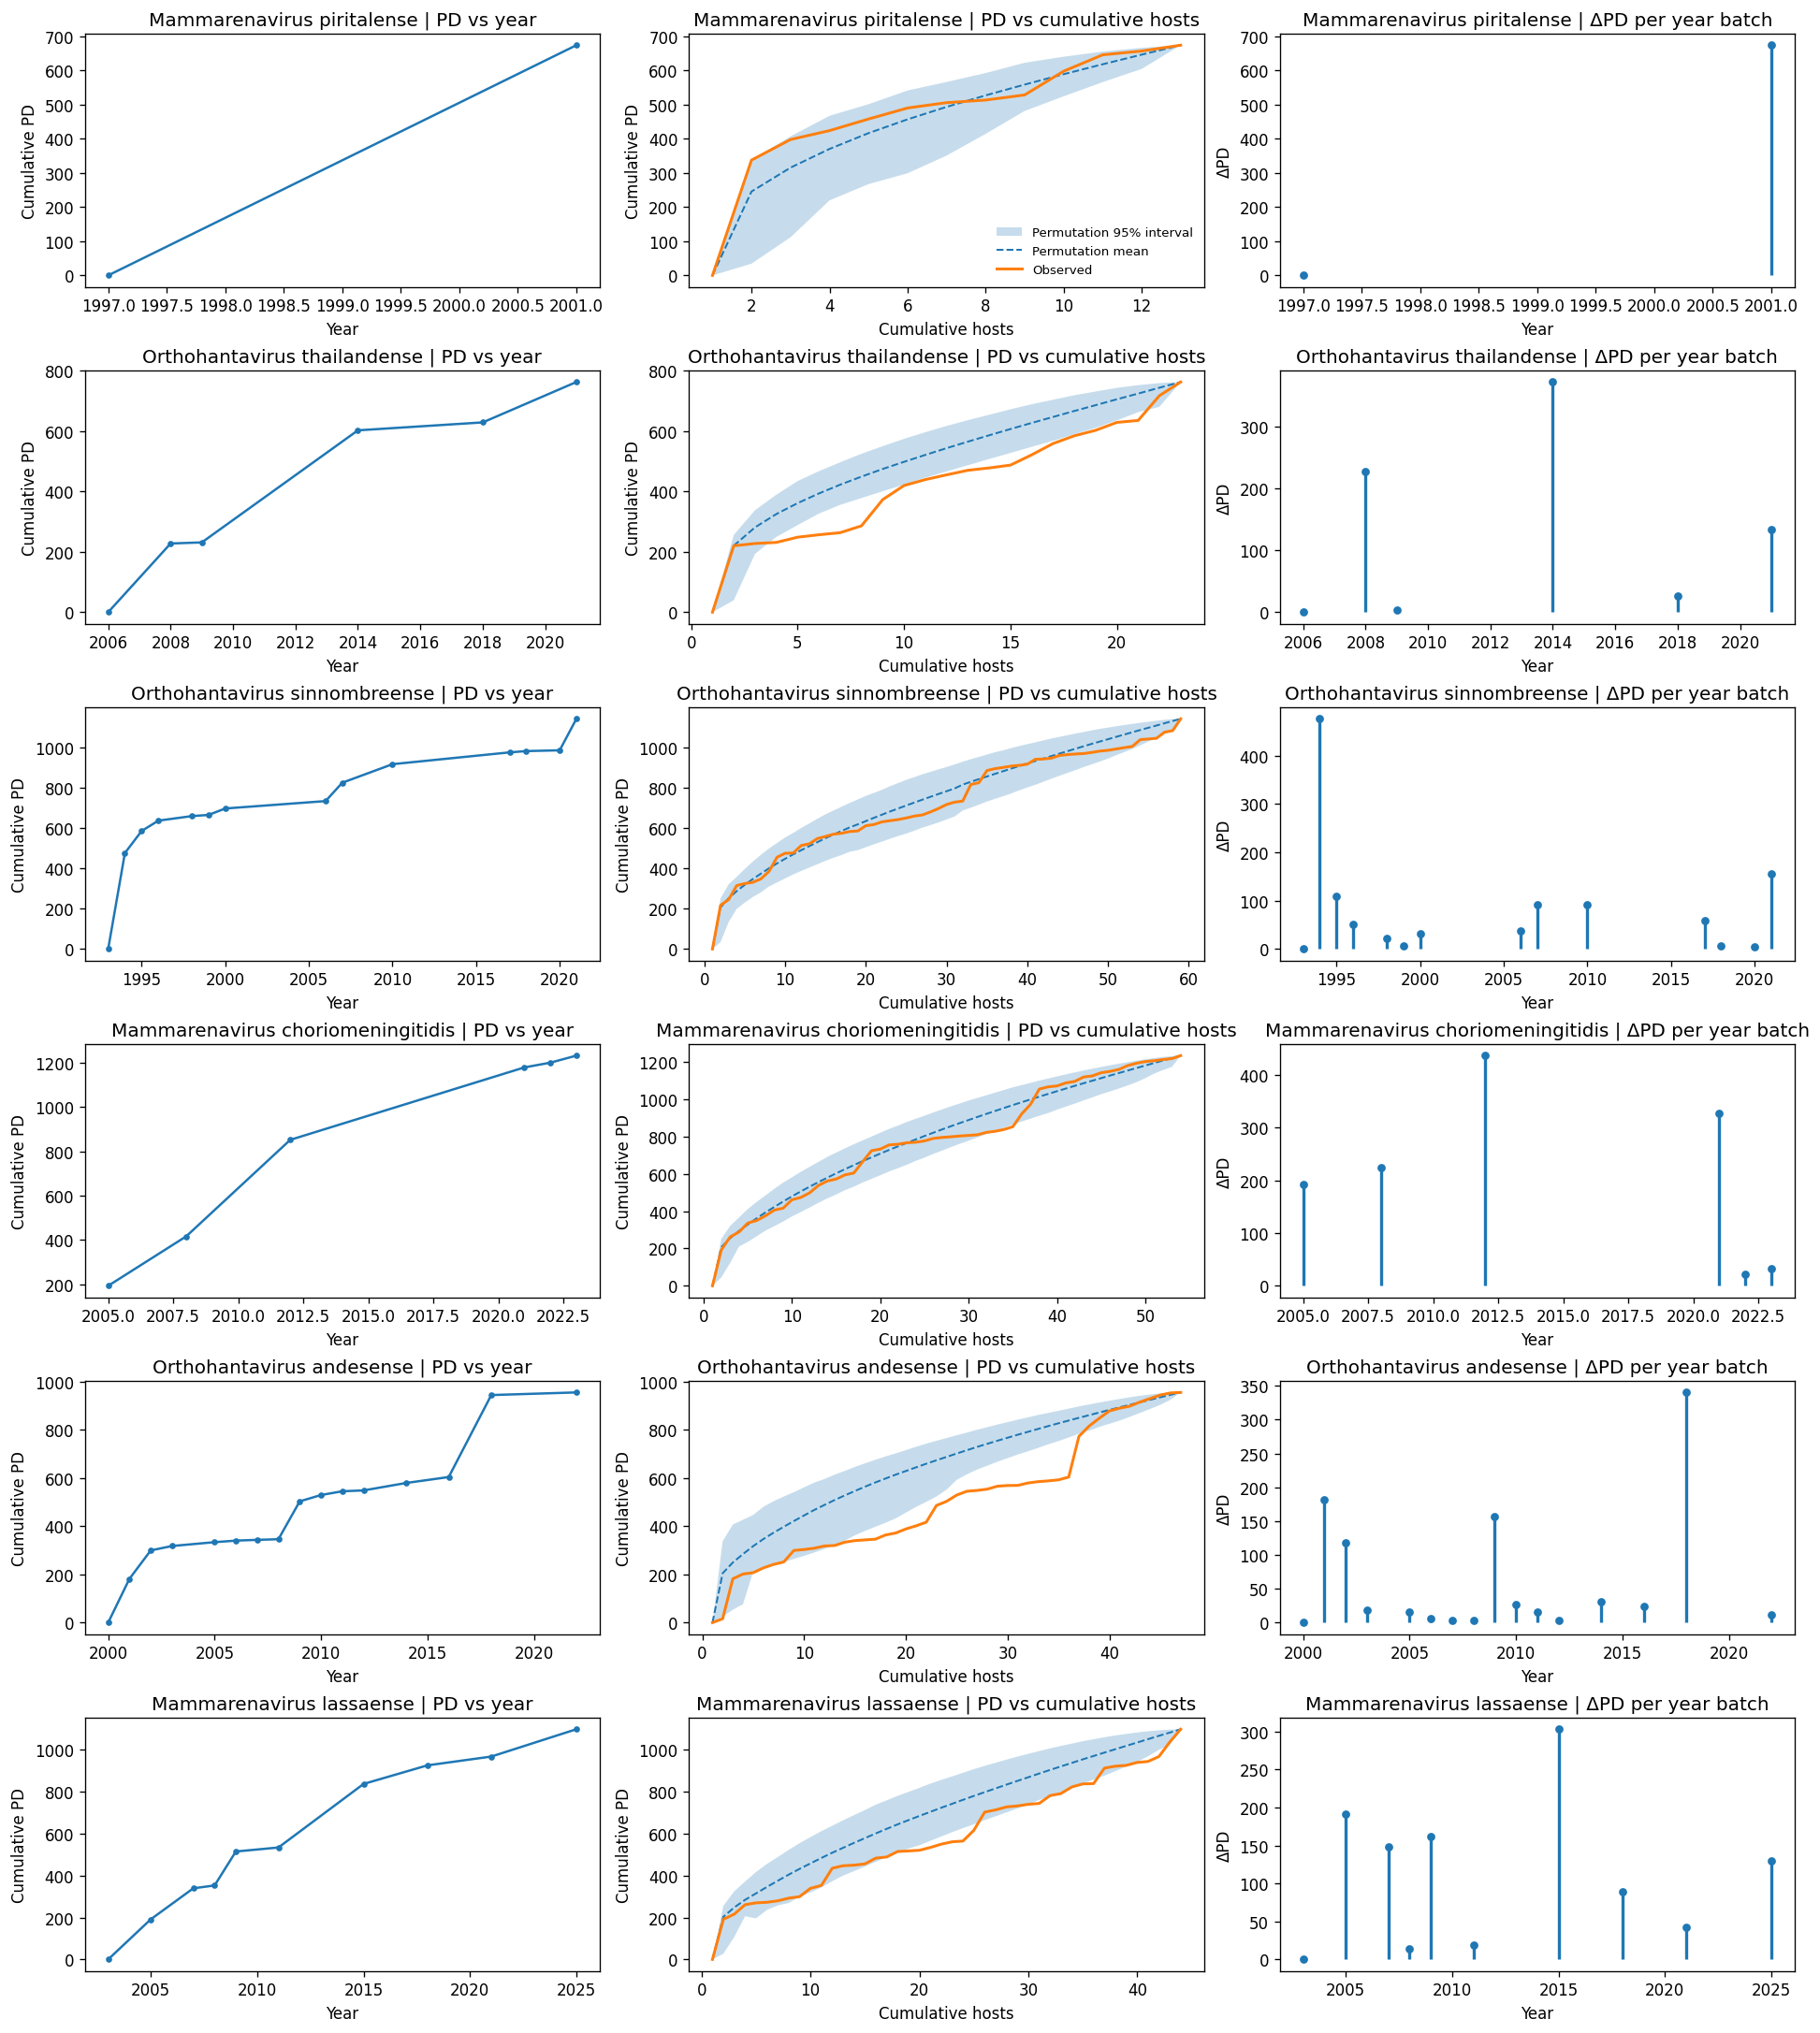

In [26]:
# Exemplar plots: PD vs year, PD vs hosts (+ permutation envelope), and ΔPD by year

def observed_hosts_in_order(v):
    d = accum_host_by_virus[v]
    if d.empty:
        return []
    return d.sort_values('host_idx')['host_tip'].tolist()


def perm_envelope_for_virus(v, r=10000, seed=1):
    hosts = observed_hosts_in_order(v)
    k = len(hosts)
    if k == 0:
        return None
    obs_curve = accum_host_by_virus[v].sort_values('host_idx')['pd_cum'].to_numpy(dtype=float)
    perms = permutation_pd_curves(hosts, r=r, seed=seed)
    return {
        'x': np.arange(1, k+1),
        'obs': obs_curve,
        'mean': np.nanmean(perms, axis=0),
        'lo': np.nanpercentile(perms, 2.5, axis=0),
        'hi': np.nanpercentile(perms, 97.5, axis=0),
    }

n = len(exemplars)
fig, axes = plt.subplots(n, 3, figsize=(16, max(3*n, 8)), constrained_layout=True)
if n == 1:
    axes = np.array([axes])

obs_color = '#2f4858'
perm_color = 'dimgrey'

for i, v in enumerate(exemplars):
    ay = accum_year_by_virus[v]

    # PD vs year
    axes[i, 0].plot(ay['year'], ay['pd_cum'], '-o', ms=3, lw=1.5)
    axes[i, 0].set_title(f'{v} | PD vs year')
    axes[i, 0].set_xlabel('Year')
    axes[i, 0].set_ylabel('Cumulative PD')

    # PD vs hosts with permutation envelope (Dudas-inspired aesthetics)
    env = perm_envelope_for_virus(v, r=R_PERM, seed=GLOBAL_SEED)

    axes[i, 1].fill_between(
        env['x'], env['lo'], env['hi'],
        facecolor='none',
        edgecolor=perm_color,
        hatch='///',
        linewidth=0.0,
        zorder=5,
        label='Permutation 95% interval' if i == 0 else None,
    )
    axes[i, 1].plot(env['x'], env['lo'], color=perm_color, lw=1.6, zorder=6)
    axes[i, 1].plot(env['x'], env['hi'], color=perm_color, lw=1.6, zorder=6)
    axes[i, 1].plot(env['x'], env['mean'], '--', color=perm_color, lw=1.4, zorder=7,
                    label='Permutation mean' if i == 0 else None)

    # observed curve with white under-stroke + foreground + outlined points
    axes[i, 1].plot(env['x'], env['obs'], '-', color='white', lw=4.8, zorder=19)
    axes[i, 1].plot(env['x'], env['obs'], '-', color=obs_color, lw=2.2, zorder=20,
                    label='Observed' if i == 0 else None)
    axes[i, 1].scatter(env['x'], env['obs'], s=34, facecolor='white', edgecolor='none', zorder=21)
    axes[i, 1].scatter(env['x'], env['obs'], s=18, facecolor=obs_color, edgecolor='none', zorder=22)

    axes[i, 1].set_title(f'{v} | PD vs cumulative hosts')
    axes[i, 1].set_xlabel('Cumulative hosts')
    axes[i, 1].set_ylabel('Cumulative PD')
    axes[i, 1].grid(axis='y', ls='--', color='lightgrey', zorder=0)
    axes[i, 1].spines['top'].set_visible(False)
    axes[i, 1].spines['right'].set_visible(False)

    if i == 0:
        axes[i, 1].legend(frameon=False, fontsize=8)

    # Delta PD by year
    axes[i, 2].vlines(ay['year'], 0, ay['delta_pd'], lw=2)
    axes[i, 2].scatter(ay['year'], ay['delta_pd'], s=18)
    axes[i, 2].set_title(f'{v} | ΔPD per year batch')
    axes[i, 2].set_xlabel('Year')
    axes[i, 2].set_ylabel('ΔPD')

for fmt in SAVE_FORMATS:
    fig.savefig(OUTPUT_DIR / f'exemplar_pd_panels.{fmt}', dpi=300, bbox_inches='tight')
plt.show()


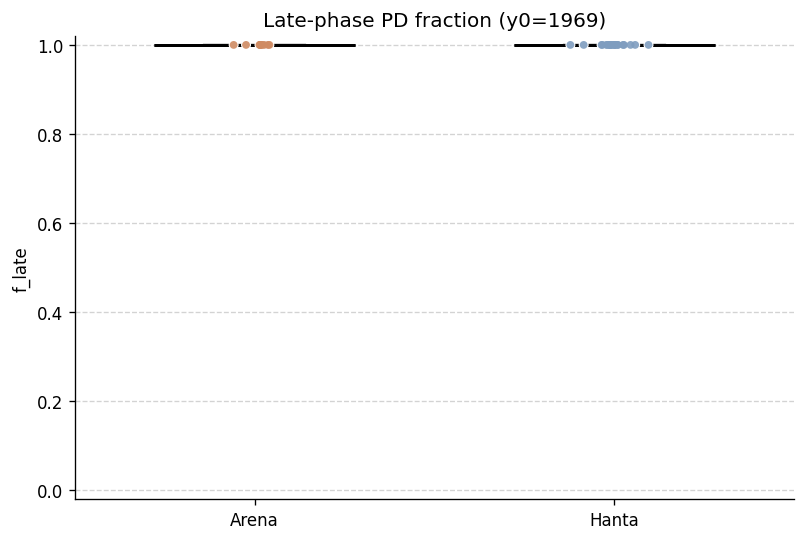

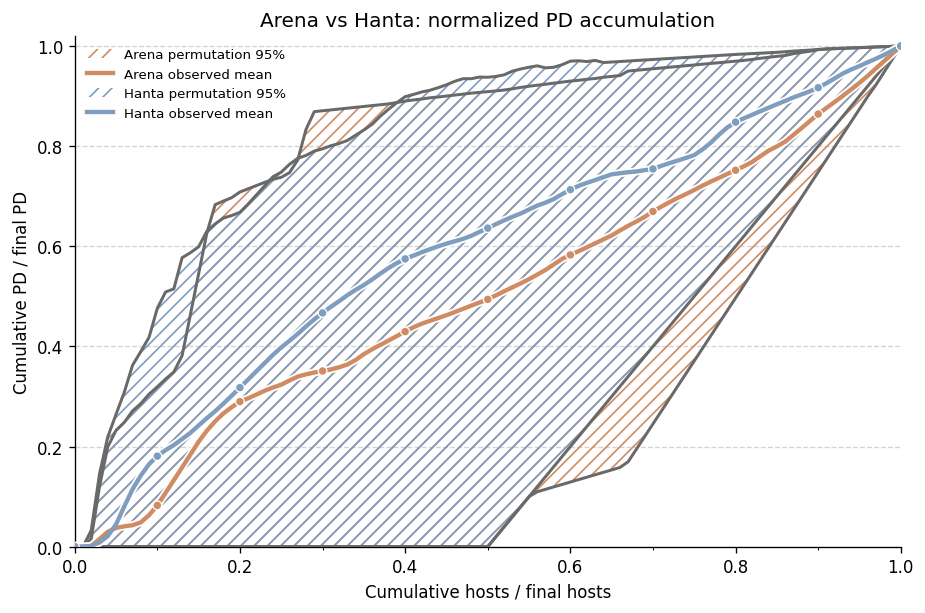

In [30]:
# Arena vs Hanta group summaries (Dudas-inspired plotting aesthetics)
import matplotlib as mpl

valid_groups = virus_summary['group'].dropna().astype(str).str.strip()
has_group = valid_groups.isin(['Arena', 'Hanta']).any() and valid_groups.nunique() >= 2

if not has_group:
    print('No explicit Arena/Hanta grouping available for robust comparison.')
    print('Set VIRUS_GROUP_MAP_PATH to a TSV with columns: virus_id, group (Arena/Hanta), then rerun from standardization cell.')
else:
    grp = virus_summary[virus_summary['group'].isin(['Arena','Hanta'])].copy()

    # Distribution of f_late
    fig, ax = plt.subplots(figsize=(6.6, 4.4), constrained_layout=True)
    arena_vals = grp.loc[grp['group']=='Arena', 'f_late_y0'].dropna()
    hanta_vals = grp.loc[grp['group']=='Hanta', 'f_late_y0'].dropna()

    bp = ax.boxplot(
        [arena_vals, hanta_vals],
        labels=['Arena','Hanta'],
        showfliers=False,
        widths=0.56,
        patch_artist=True,
        boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
        medianprops=dict(color='black', linewidth=1.8),
        whiskerprops=dict(color='black', linewidth=1.3),
        capprops=dict(color='black', linewidth=1.3),
    )

    rng_j = np.random.default_rng(1)
    point_cols = {'Arena': '#cf8b63', 'Hanta': '#7f9dbf'}
    for j, (gname, vals) in enumerate([('Arena', arena_vals), ('Hanta', hanta_vals)], start=1):
        x = rng_j.normal(j, 0.045, size=len(vals))
        # white underlay + coloured foreground to mimic outlined points
        ax.scatter(x, vals, s=36, facecolor='white', edgecolor='none', zorder=4)
        ax.scatter(x, vals, s=22, facecolor=point_cols[gname], edgecolor='none', alpha=0.9, zorder=5)

    ax.set_title(f'Late-phase PD fraction (y0={Y0})')
    ax.set_ylabel('f_late')
    ax.grid(axis='y', ls='--', color='lightgrey', zorder=0)
    ax.set_ylim(-0.02, 1.02)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for fmt in SAVE_FORMATS:
        fig.savefig(OUTPUT_DIR / f'group_flate_y0_{Y0}.{fmt}', dpi=300, bbox_inches='tight')
    plt.show()

    # Mean normalized PD(n) + permutation envelope
    grid = np.linspace(0.0, 1.0, 101)

    def interp_curve(x, y):
        x2 = np.asarray(x, dtype=float)
        y2 = np.asarray(y, dtype=float)
        x2 = np.concatenate([[0.0], x2])
        y2 = np.concatenate([[0.0], y2])
        return np.interp(grid, x2, y2)

    fig, ax = plt.subplots(figsize=(7.6, 5.0), constrained_layout=True)

    for g, color in [('Arena', '#cf8b63'), ('Hanta', '#7f9dbf')]:
        g_viruses = grp.loc[grp['group']==g, 'virus_id'].tolist()
        obs_curves = []
        perm_curves = []

        for v in g_viruses:
            ah = accum_host_by_virus[v].sort_values('host_idx')
            if ah.empty:
                continue
            k = int(ah['n_hosts_cum'].max())
            if k < 2:
                continue
            pd_final = float(ah['pd_cum'].iloc[-1])
            if not np.isfinite(pd_final) or pd_final <= 0:
                continue

            x_obs = ah['n_hosts_cum'].to_numpy(dtype=float) / k
            y_obs = ah['pd_cum'].to_numpy(dtype=float) / pd_final
            obs_curves.append(interp_curve(x_obs, y_obs))

            hosts = observed_hosts_in_order(v)
            perm = permutation_pd_curves(hosts, r=R_PERM, seed=GLOBAL_SEED)
            x_perm = np.arange(1, k+1, dtype=float) / k
            for r_i in range(perm.shape[0]):
                y_perm = perm[r_i] / pd_final
                perm_curves.append(interp_curve(x_perm, y_perm))

        if len(obs_curves) == 0:
            continue

        obs_arr = np.vstack(obs_curves)
        obs_mean = np.nanmean(obs_arr, axis=0)

        if len(perm_curves) > 0:
            perm_arr = np.vstack(perm_curves)
            lo = np.nanpercentile(perm_arr, 2.5, axis=0)
            hi = np.nanpercentile(perm_arr, 97.5, axis=0)
            # hatched null envelope, Dudas-like
            ax.fill_between(
                grid, lo, hi,
                facecolor='none',
                edgecolor=color,
                hatch='///',
                linewidth=0.0,
                zorder=5,
                label=f'{g} permutation 95%'
            )
            ax.plot(grid, lo, color='dimgrey', lw=1.8, zorder=6)
            ax.plot(grid, hi, color='dimgrey', lw=1.8, zorder=6)

        # white under-stroke + coloured foreground line
        ax.plot(grid, obs_mean, color='white', lw=4.8, zorder=19)
        ax.plot(grid, obs_mean, color=color, lw=2.6, zorder=20, label=f'{g} observed mean')

        # sparse points for curve emphasis
        idx = np.arange(0, len(grid), 10)
        ax.scatter(grid[idx], obs_mean[idx], s=36, facecolor='white', edgecolor='none', zorder=21)
        ax.scatter(grid[idx], obs_mean[idx], s=20, facecolor=color, edgecolor='none', zorder=22)

    ax.set_title('Arena vs Hanta: normalized PD accumulation')
    ax.set_xlabel('Cumulative hosts / final hosts')
    ax.set_ylabel('Cumulative PD / final PD')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)

    ax.grid(axis='y', ls='--', color='lightgrey', zorder=0)
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(frameon=False, fontsize=8, ncol=1)

    for fmt in SAVE_FORMATS:
        fig.savefig(OUTPUT_DIR / f'group_normalized_pd_envelope.{fmt}', dpi=300, bbox_inches='tight')
    plt.show()


Saved: /Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/cophylogeny/pd_saturation_outputs/f_late_sensitivity.csv


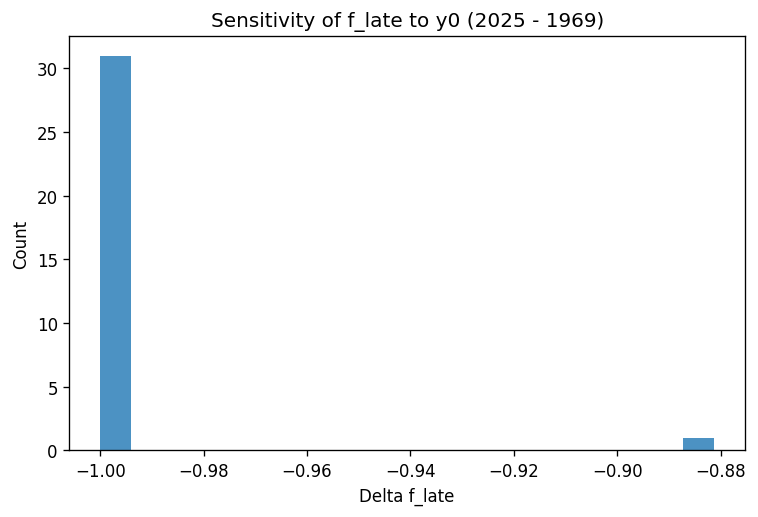

,virus_id,group,f_late_1969,f_late_2025,delta
0,Mammarenavirus bearense,Arena,1.0,0.000000,-1.000000
1,Mammarenavirus choriomeningitidis,Arena,1.0,0.000000,-1.000000
2,Mammarenavirus gairoense,Arena,NaN,NaN,NaN
3,Mammarenavirus guanaritoense,Arena,1.0,0.000000,-1.000000
4,Mammarenavirus juninense,Arena,1.0,0.000000,-1.000000
5,Mammarenavirus lassaense,Arena,1.0,0.118744,-0.881256
6,Mammarenavirus latinum,Arena,1.0,0.000000,-1.000000
7,Mammarenavirus lunaense,Arena,NaN,NaN,NaN
8,Mammarenavirus lunkense,Arena,NaN,NaN,NaN
9,Mammarenavirus mopeiaense,Arena,NaN,NaN,NaN


In [28]:
# Surveillance-era sensitivity check
sens = virus_summary[['virus_id', 'group', 'f_late_y0', 'f_late_y0_alt']].copy()
sens = sens.rename(columns={'f_late_y0': f'f_late_{Y0}', 'f_late_y0_alt': f'f_late_{Y0_ALT}'})
sens['delta'] = sens[f'f_late_{Y0_ALT}'] - sens[f'f_late_{Y0}']

sens.to_csv(OUTPUT_DIR / 'f_late_sensitivity.csv', index=False)
print('Saved:', OUTPUT_DIR / 'f_late_sensitivity.csv')

fig, ax = plt.subplots(figsize=(6.2, 4.2), constrained_layout=True)
ax.hist(sens['delta'].dropna(), bins=20, alpha=0.8)
ax.set_title(f'Sensitivity of f_late to y0 ({Y0_ALT} - {Y0})')
ax.set_xlabel('Delta f_late')
ax.set_ylabel('Count')

for fmt in SAVE_FORMATS:
    fig.savefig(OUTPUT_DIR / f'f_late_sensitivity_hist_{Y0}_{Y0_ALT}.{fmt}', dpi=300, bbox_inches='tight')

plt.show()
sens.head(10)


In [29]:
# Final export summary
print('Output directory:', OUTPUT_DIR)
print('Key files:')
for name in [
    'virus_summary.csv',
    'per_virus_pd_by_year.csv',
    'per_virus_pd_by_hosts.csv',
    'exemplar_viruses.csv',
    'f_late_sensitivity.csv',
    'unmatched_host_labels.tsv',
]:
    p = OUTPUT_DIR / name
    print(' -', p, '| exists:', p.exists())

print('Figures exported as:', SAVE_FORMATS)


Output directory: /Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/cophylogeny/pd_saturation_outputs
Key files:
 - /Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/cophylogeny/pd_saturation_outputs/virus_summary.csv | exists: True
 - /Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/cophylogeny/pd_saturation_outputs/per_virus_pd_by_year.csv | exists: True
 - /Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/cophylogeny/pd_saturation_outputs/per_virus_pd_by_hosts.csv | exists: True
 - /Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/cophylogeny/pd_saturation_outputs/exemplar_viruses.csv | exists: True
 - /Users/ricardorivero/Documents/GitHub/arha-macroecology/data/processed/arenavirus_hantavirus/cophylogeny/pd_saturation_outputs/f_late_sensitivity.csv | exists: True
 - /Us